# Structured API Implementation (High-Level) for Decision Tree

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import NumericType

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [ ]:
spark = SparkSession.builder.appName("StructuredAPI").getOrCreate()
data = spark.read.csv("hdfs://172.17.0.2:9000/user/khtn_22120182/train.csv", header=True, inferSchema=True)

25/05/10 10:55:23 WARN Utils: Your hostname, dyln resolves to a loopback address: 127.0.1.1; using 192.168.1.37 instead (on interface wlp0s20f3)
25/05/10 10:55:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/10 10:55:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
features = [col for col in data.columns if col != "trip_duration"]
label = 'trip_duration'

In [4]:
class StructuredAPI:
    def __init__(self, data, features, label):
        self.data = data
        self.features = features
        self.label = label
        self.model = None
        self.predictions = None

    def preprocess(self):
        self.data = self.data.dropna(subset=self.features + [self.label])

        self.numeric_features = [field.name for field in self.data.schema.fields if isinstance(field.dataType, NumericType)]
        # Remove trip_duration from numeric features
        self.numeric_features = [feature for feature in self.numeric_features if feature != self.label]

        # Assemble features
        assembler = VectorAssembler(inputCols=self.numeric_features, outputCol="features")
        self.data = assembler.transform(self.data).select("features", self.label)

        self.train_data, self.test_data = self.data.randomSplit([0.8, 0.2], seed=0)

    def fit(self, max_depth=5):
        dt = DecisionTreeRegressor(featuresCol="features", labelCol=self.label, maxDepth=max_depth)
        self.model = dt.fit(self.train_data)

    def evaluate(self):
        self.predictions = self.model.transform(self.test_data)

        evaluator = RegressionEvaluator(labelCol=self.label, predictionCol="prediction")
        rmse = evaluator.evaluate(self.predictions, {evaluator.metricName: "rmse"})
        r2 = evaluator.evaluate(self.predictions, {evaluator.metricName: "r2"})

        return rmse, r2

    def plot_feature_importance(self, top_n=None):
        import matplotlib.pyplot as plt
          
        importances = self.model.featureImportances.toArray()
        feature_names = self.numeric_features

        sorted_indices = importances.argsort()[::-1]
        if top_n:
            sorted_indices = sorted_indices[:top_n]

        plt.figure(figsize=(10, 6))
        plt.bar([feature_names[i] + f" (feature {i})" for i in sorted_indices],
                importances[sorted_indices],
                color="skyblue")
        plt.xlabel("Features")
        plt.ylabel("Importance")
        plt.title("Feature Importances")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    def print_tree(self):
        print("Tree Structure:\n")
        print(self.model.toDebugString)

In [5]:
model = StructuredAPI(data, features, label)
model.preprocess()
model.fit(max_depth=3)
rmse, r2 = model.evaluate()

25/05/10 10:55:40 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


RMSE: 6288.530004971957
R2: 0.004556815634278011
Tree Structure:

DecisionTreeRegressionModel: uid=DecisionTreeRegressor_4d3c3fbe2d4a, depth=3, numNodes=15, numFeatures=6
  If (feature 2 <= -73.87304306030273)
   If (feature 4 <= -73.9091796875)
    If (feature 5 <= 40.70473098754883)
     Predict: 1424.5187217088383
    Else (feature 5 > 40.70473098754883)
     Predict: 828.6759784893593
   Else (feature 4 > -73.9091796875)
    If (feature 5 <= 40.70473098754883)
     Predict: 2882.6975546975546
    Else (feature 5 > 40.70473098754883)
     Predict: 1724.1953534848863
  Else (feature 2 > -73.87304306030273)
   If (feature 4 <= -73.9611701965332)
    If (feature 3 <= 40.6866512298584)
     Predict: 3327.616963336876
    Else (feature 3 > 40.6866512298584)
     Predict: 2260.529125592114
   Else (feature 4 > -73.9611701965332)
    If (feature 4 <= -73.9091796875)
     Predict: 1957.6099535894145
    Else (feature 4 > -73.9091796875)
     Predict: 1260.790385403854



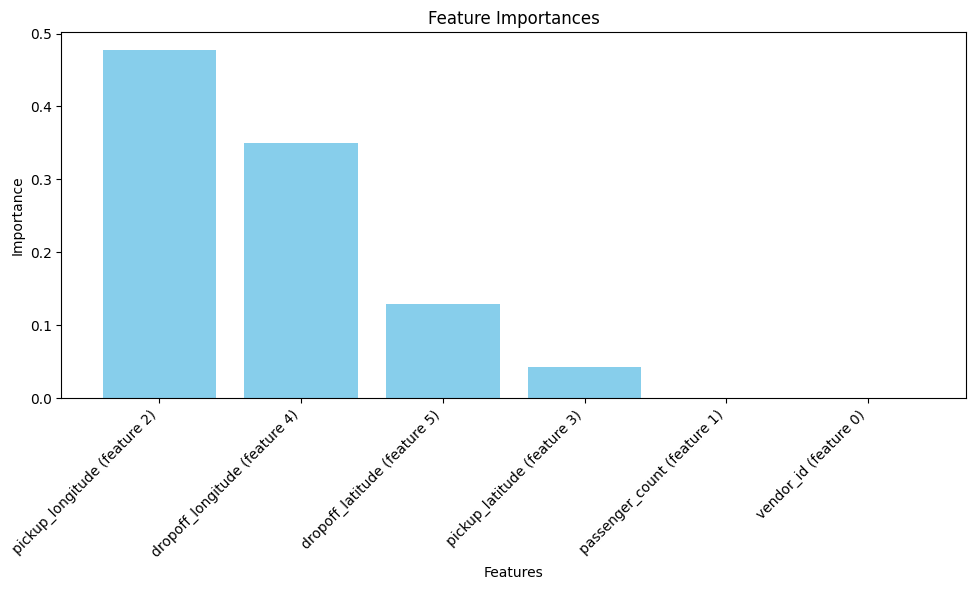

In [6]:
print("RMSE:", rmse)
print("R2:", r2)
model.print_tree()
model.plot_feature_importance()

In [7]:
model.fit(max_depth=5)
rmse, r2 = model.evaluate()

RMSE: 6288.359505585617
R2: 0.004610793320991791
Tree Structure:

DecisionTreeRegressionModel: uid=DecisionTreeRegressor_ca3b011eeb0f, depth=5, numNodes=63, numFeatures=6
  If (feature 2 <= -73.87304306030273)
   If (feature 4 <= -73.9091796875)
    If (feature 5 <= 40.70473098754883)
     If (feature 3 <= 40.72654914855957)
      If (feature 3 <= 40.71245193481445)
       Predict: 795.9229492650545
      Else (feature 3 > 40.71245193481445)
       Predict: 1231.7804682005426
     Else (feature 3 > 40.72654914855957)
      If (feature 5 <= 40.68045425415039)
       Predict: 2100.181653659088
      Else (feature 5 > 40.68045425415039)
       Predict: 1660.95306530835
    Else (feature 5 > 40.70473098754883)
     If (feature 0 <= 1.5)
      If (feature 2 <= -73.9458236694336)
       Predict: 707.6124771018718
      Else (feature 2 > -73.9458236694336)
       Predict: 1062.161473561106
     Else (feature 0 > 1.5)
      If (feature 4 <= -73.9398422241211)
       Predict: 915.8715511410161


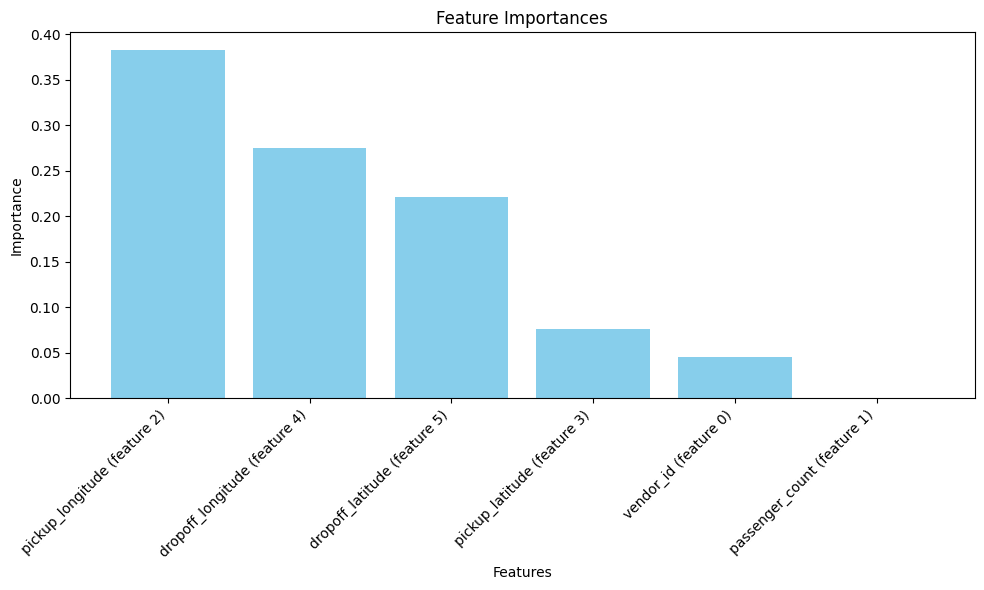

In [8]:
print("RMSE:", rmse)
print("R2:", r2)
model.print_tree()
model.plot_feature_importance()

In [9]:
model.fit(max_depth=7)
rmse, r2 = model.evaluate()

RMSE: 6333.8885416933335
R2: -0.0098550370776469
Tree Structure:

DecisionTreeRegressionModel: uid=DecisionTreeRegressor_d15435a42e1b, depth=7, numNodes=255, numFeatures=6
  If (feature 2 <= -73.87304306030273)
   If (feature 4 <= -73.9091796875)
    If (feature 5 <= 40.70473098754883)
     If (feature 3 <= 40.72654914855957)
      If (feature 3 <= 40.71245193481445)
       If (feature 2 <= -74.00315475463867)
        If (feature 4 <= -73.96369934082031)
         Predict: 904.4190268700073
        Else (feature 4 > -73.96369934082031)
         Predict: 1746.3346153846153
       Else (feature 2 > -74.00315475463867)
        If (feature 4 <= -73.96725845336914)
         Predict: 611.9137611275964
        Else (feature 4 > -73.96725845336914)
         Predict: 845.8640922768305
      Else (feature 3 > 40.71245193481445)
       If (feature 4 <= -73.96725845336914)
        If (feature 5 <= 40.68045425415039)
         Predict: 1375.2436781609194
        Else (feature 5 > 40.68045425415039)
 

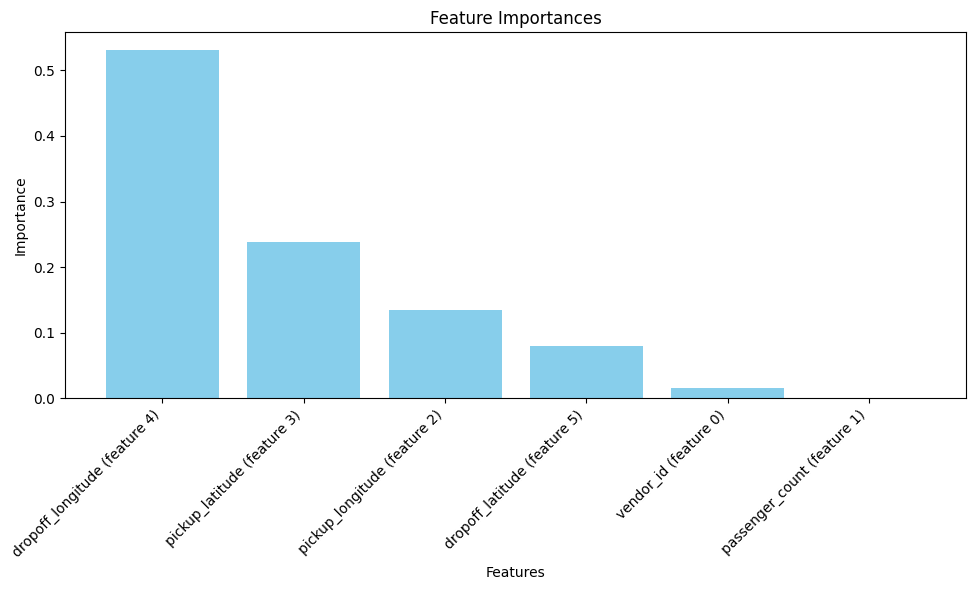

In [10]:
print("RMSE:", rmse)
print("R2:", r2)
model.print_tree()
model.plot_feature_importance()

In [ ]:
spark.stop()